# 🎧 Signal Processing Basics with Librosa

## 📌 1. Setup & Installation

In [1]:
!pip install librosa matplotlib numpy scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

## 📌 2. Load an Audio Signal

## 📌 3. Waveform Visualization

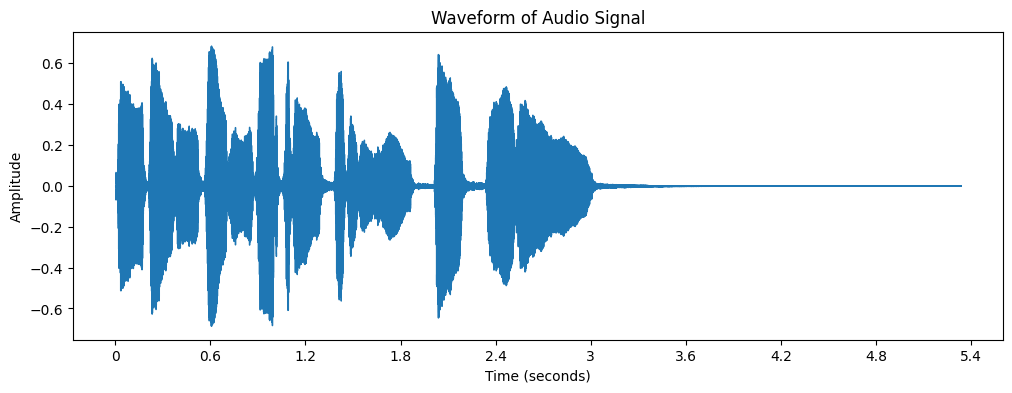

In [4]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Audio Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

## 📌 4. Basic Signal Properties

In [5]:
duration = librosa.get_duration(y=y, sr=sr)
print(f"Duration: {duration:.2f} seconds")

print(f"Max Amplitude: {np.max(y)}")
print(f"Min Amplitude: {np.min(y)}")

Duration: 5.33 seconds
Max Amplitude: 0.6315985321998596
Min Amplitude: -0.6847599148750305


## 📌 5. Short-Time Fourier Transform (STFT)

The Short-Time Fourier Transform (STFT) is a technique used to analyze how the frequency content of a signal changes over time. It splits the signal into small overlapping time windows and applies the Fourier Transform to each window, producing a time–frequency representation.

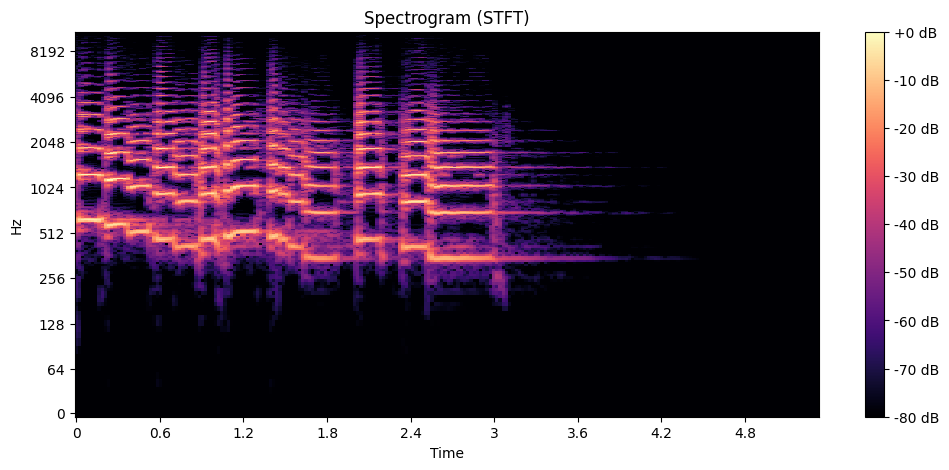

In [6]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram (STFT)")
plt.show()

## 📌 6. Mel Spectrogram

A Mel Spectrogram is a representation of the signal’s frequency content mapped onto the Mel scale, which approximates human auditory perception. It compresses higher frequencies and emphasizes perceptually important features, making it widely used in speech and audio processing.

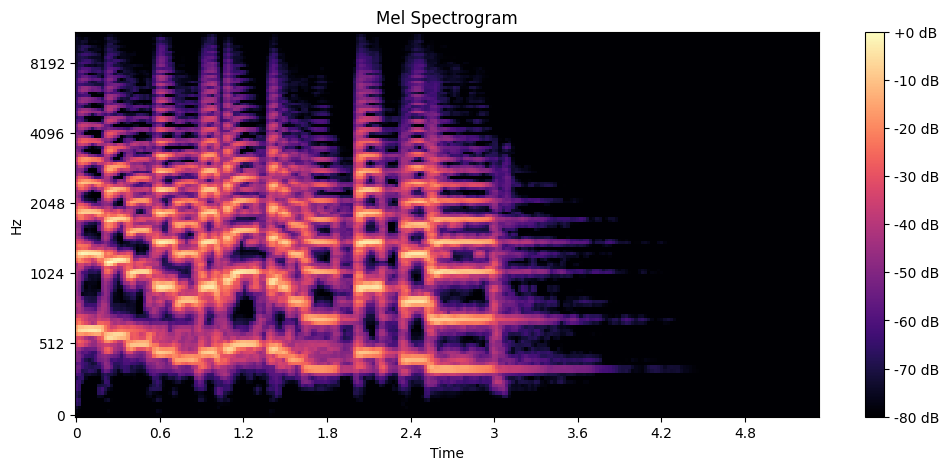

In [7]:
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

## 📌 7. Zero Crossing Rate (ZCR)

The Zero Crossing Rate (ZCR) measures how frequently a signal changes sign (crosses zero) within a frame. It is commonly used to distinguish between noisy and tonal signals, with higher values indicating more noise-like characteristics.

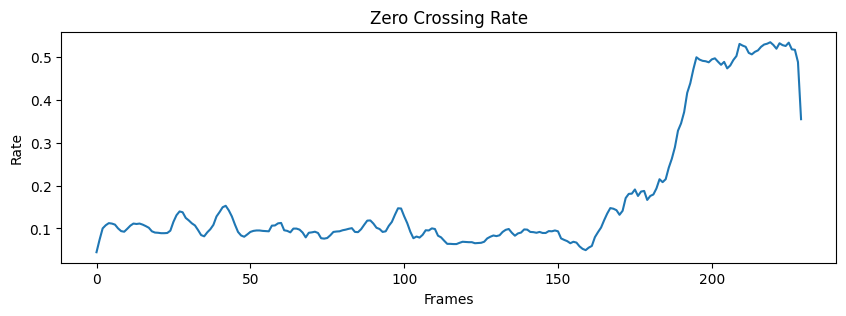

In [8]:
zcr = librosa.feature.zero_crossing_rate(y)

plt.figure(figsize=(10, 3))
plt.plot(zcr[0])
plt.title("Zero Crossing Rate")
plt.xlabel("Frames")
plt.ylabel("Rate")
plt.show()

## 📌 8. Spectral Centroid

The Spectral Centroid represents the “center of mass” of the spectrum. It indicates where the majority of the signal’s energy is concentrated in the frequency domain and is often associated with the perceived brightness of a sound.

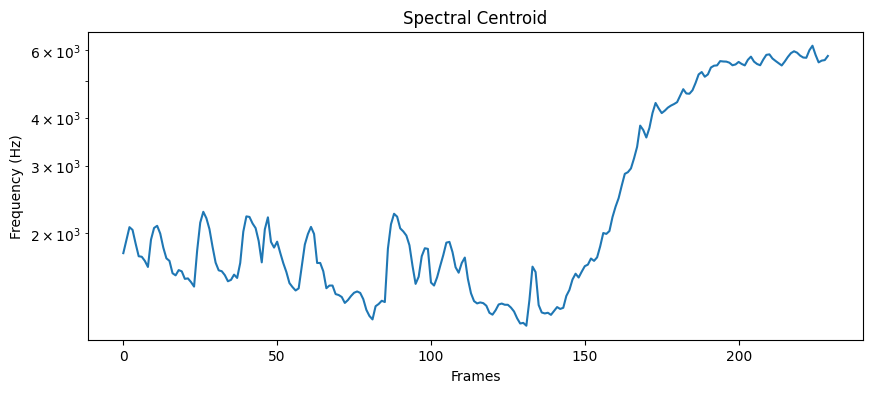

In [10]:
centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

plt.figure(figsize=(10, 4))
plt.semilogy(centroid.T)
plt.title("Spectral Centroid")
plt.xlabel("Frames")
plt.ylabel("Frequency (Hz)")
plt.show()

## 📌 9. MFCC

MFCCs are features extracted from the Mel Spectrogram that capture the spectral shape of audio signals. They are computed by taking the logarithm of Mel-scaled energies and applying a Discrete Cosine Transform (DCT), making them effective for speech and audio recognition tasks.

In [ ]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(12, 5))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")
plt.show()

## 📌 10. Tempo & Beat Tracking

Tempo and Beat Tracking involves estimating the speed (tempo, usually in beats per minute) and identifying the timing of beats in an audio signal. It is widely used in music analysis, rhythm detection, and synchronization tasks.

In [ ]:
tempo, beats = librosa.beat.beat_track(y=y, sr=sr)

print(f"Estimated Tempo: {tempo} BPM")

## 📌 11. Harmonic vs Percussive Separation

This technique separates an audio signal into two components:

Harmonic: Sustained, tonal sounds (e.g., vocals, instruments)
Percussive: Short, transient sounds (e.g., drums, beats)

It is typically achieved using signal decomposition methods based on time-frequency characteristics.

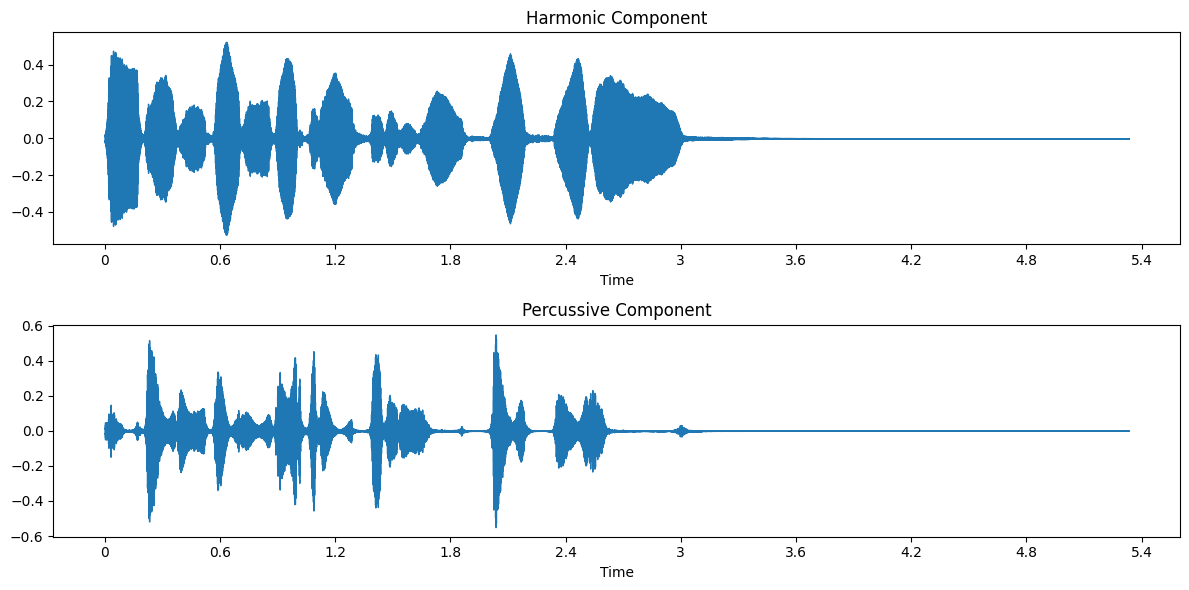

In [11]:
y_harm, y_perc = librosa.effects.hpss(y)

plt.figure(figsize=(12, 6))

plt.subplot(2,1,1)
librosa.display.waveshow(y_harm, sr=sr)
plt.title("Harmonic Component")

plt.subplot(2,1,2)
librosa.display.waveshow(y_perc, sr=sr)
plt.title("Percussive Component")

plt.tight_layout()
plt.show()

## 📌 12. Mini Experiment

In [ ]:
file_path = "your_audio.wav"
y, sr = librosa.load(file_path)

# Plot waveform and spectrogram